In [1]:
# Install missing library
!pip install kornia -q

import torch
print(f"GPU Available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU Name: {torch.cuda.get_device_name(0)}")

GPU Available: True
GPU Name: Tesla T4


In [2]:
import os

print("Searching for your uploaded files...")
found_path = None

# This searches every single folder in Kaggle for your model.py file
for root, dirs, files in os.walk('/kaggle/input'):
    if 'model.py' in files:
        found_path = root
        print(f"\n✅ FOUND IT! The correct path is:\n{found_path}")
        print("\nFiles in this folder:")
        for f in files:
            print(f" - {f}")
        break

if not found_path:
    print("\n❌ Could not find model.py anywhere. Did the dataset finish attaching?")

Searching for your uploaded files...

✅ FOUND IT! The correct path is:
/kaggle/input/datasets/dhyeyraval/rsfnet-frozen-weights/Kaggle_Upload

Files in this folder:
 - config.json
 - losses.py
 - model.py
 - RRNet_lolv1_49.pt


In [3]:
import sys
import os
import json
import torch

# 1. Define the path to your uploaded files
MODEL_DIR = '/kaggle/input/datasets/dhyeyraval/rsfnet-frozen-weights/Kaggle_Upload'
sys.path.append(MODEL_DIR)

# Import your model architecture from the uploaded model.py
from model import RRNet

# 2. Load the config blueprint
config_path = os.path.join(MODEL_DIR, 'config.json')
with open(config_path, 'r') as f:
    config_dict = json.load(f)

# Convert the dictionary into an object so the model can read it
class ConfigParser:
    def __init__(self, data):
        for key, value in data.items():
            setattr(self, key, value)

config = ConfigParser(config_dict['config'])

# Force the model to use the Kaggle GPU
config.device = 'cuda' if torch.cuda.is_available() else 'cpu'

# 3. Initialize the empty model structure
print("Building model structure...")
model = RRNet(config)

# 4. Load your trained weights
print("Loading weights...")
weights_path = os.path.join(MODEL_DIR, 'RRNet_lolv1_49.pt')
state_dict = torch.load(weights_path, map_location=config.device)
model.load_state_dict(state_dict)

# 5. Lock it down! (Evaluation Mode)
model.eval()
model.to(config.device)

print("✅ Model successfully loaded and frozen!")

Building model structure...
Loading weights...
✅ Model successfully loaded and frozen!


In [4]:
import glob
import os

print("Searching for any image files in Kaggle...")
# Search for ALL png and jpg files anywhere in the input folder
all_images = glob.glob('/kaggle/input/**/*.png', recursive=True) + glob.glob('/kaggle/input/**/*.jpg', recursive=True)

print(f"Total images found: {len(all_images)}\n")

if len(all_images) > 0:
    print("Here is the exact folder structure for the first 10 images:")
    for img in all_images[:10]:
        print(img)
else:
    print("❌ ZERO images found. The GoPro dataset might not be attached to the notebook properly!")
    print("Currently attached datasets:")
    print(os.listdir('/kaggle/input/'))

Searching for any image files in Kaggle...
Total images found: 2058

Here is the exact folder structure for the first 10 images:
/kaggle/input/datasets/rahulbhalley/gopro-deblur/gopro_deblur/sharp/images/000585.png
/kaggle/input/datasets/rahulbhalley/gopro-deblur/gopro_deblur/sharp/images/000313.png
/kaggle/input/datasets/rahulbhalley/gopro-deblur/gopro_deblur/sharp/images/000603.png
/kaggle/input/datasets/rahulbhalley/gopro-deblur/gopro_deblur/sharp/images/000224.png
/kaggle/input/datasets/rahulbhalley/gopro-deblur/gopro_deblur/sharp/images/000121.png
/kaggle/input/datasets/rahulbhalley/gopro-deblur/gopro_deblur/sharp/images/000598.png
/kaggle/input/datasets/rahulbhalley/gopro-deblur/gopro_deblur/sharp/images/000750.png
/kaggle/input/datasets/rahulbhalley/gopro-deblur/gopro_deblur/sharp/images/000546.png
/kaggle/input/datasets/rahulbhalley/gopro-deblur/gopro_deblur/sharp/images/000572.png
/kaggle/input/datasets/rahulbhalley/gopro-deblur/gopro_deblur/sharp/images/002503.png


In [5]:
import os
import glob
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import torchvision.transforms.functional as TF
import torchvision.transforms as transforms
import random

class GoProDataset(Dataset):
    def __init__(self, root_dir, split='train', patch_size=256):
        self.patch_size = patch_size
        
        # We now target the EXACT path the detective script found
        search_path = os.path.join(root_dir, 'blur', 'images', '*.png')
        all_blur_paths = glob.glob(search_path)
        all_blur_paths.sort()
        
        if len(all_blur_paths) == 0:
            raise FileNotFoundError(f"CRITICAL ERROR: No images found in {search_path}!")
            
        # Split into 80% train, 20% test
        random.seed(42)
        random.shuffle(all_blur_paths)
        
        split_idx = int(len(all_blur_paths) * 0.8)
        if split == 'train':
            self.blur_paths = all_blur_paths[:split_idx]
        else:
            self.blur_paths = all_blur_paths[split_idx:]
            
        print(f"✅ Loaded {len(self.blur_paths)} images for the {split} split.")

    def __len__(self):
        return len(self.blur_paths)

    def __getitem__(self, idx):
        blur_path = self.blur_paths[idx]
        
        # Simply swap the word 'blur' with 'sharp' to get the clean image path
        sharp_path = blur_path.replace('/blur/', '/sharp/')
        
        # Load images
        blur_img = Image.open(blur_path).convert('RGB')
        sharp_img = Image.open(sharp_path).convert('RGB')
        
        # Synchronized Random Crop
        i, j, h, w = transforms.RandomCrop.get_params(blur_img, output_size=(self.patch_size, self.patch_size))
        blur_img = TF.crop(blur_img, i, j, h, w)
        sharp_img = TF.crop(sharp_img, i, j, h, w)
        
        # Convert to PyTorch Tensors
        blur_tensor = TF.to_tensor(blur_img)
        sharp_tensor = TF.to_tensor(sharp_img)
        
        return blur_tensor, sharp_tensor

# The exact base directory found by our script
GOPRO_DIR = '/kaggle/input/datasets/rahulbhalley/gopro-deblur/gopro_deblur'

train_dataset = GoProDataset(GOPRO_DIR, split='train')
test_dataset = GoProDataset(GOPRO_DIR, split='test')

# Grab one pair to verify shapes
blur, sharp = train_dataset[0]
print(f"Tensor shapes -> Blur: {blur.shape}, Sharp: {sharp.shape}")

✅ Loaded 823 images for the train split.
✅ Loaded 206 images for the test split.
Tensor shapes -> Blur: torch.Size([3, 256, 256]), Sharp: torch.Size([3, 256, 256])


In [6]:
import torch.nn as nn
import torch.nn.functional as F

class ModifiedAirNet(nn.Module):
    def __init__(self, in_channels=18, out_channels=3):
        super(ModifiedAirNet, self).__init__()
        
        # Encoder (Compresses the 18 channels down to find the deep structure)
        self.enc1 = nn.Conv2d(in_channels, 64, kernel_size=3, padding=1)
        self.enc2 = nn.Conv2d(64, 128, kernel_size=3, padding=1, stride=2)
        self.enc3 = nn.Conv2d(128, 256, kernel_size=3, padding=1, stride=2)
        
        # Bottleneck
        self.bottle = nn.Conv2d(256, 256, kernel_size=3, padding=1)
        
        # Decoder (Expands back to full resolution)
        self.dec1 = nn.ConvTranspose2d(256, 128, kernel_size=4, stride=2, padding=1)
        self.dec2 = nn.ConvTranspose2d(128, 64, kernel_size=4, stride=2, padding=1)
        
        # Final Output Layer (Compresses back to 3 RGB channels)
        self.out = nn.Conv2d(64, out_channels, kernel_size=3, padding=1)
        self.relu = nn.ReLU(inplace=True)

    def forward(self, x):
        # x contains the 3-channel blurry image AND the 15-channel factors
        original_blur = x[:, :3, :, :] 
        
        e1 = self.relu(self.enc1(x))
        e2 = self.relu(self.enc2(e1))
        e3 = self.relu(self.enc3(e2))
        
        b = self.relu(self.bottle(e3))
        
        d1 = self.relu(self.dec1(b))
        d2 = self.relu(self.dec2(d1 + e2)) # Skip connection to preserve details
        
        out = self.out(d2 + e1)
        
        # Global Residual Learning: 
        # We add the output to the original blurry image. 
        # This forces the network to only learn the "difference" (the blur removal)
        final_img = out + original_blur
        
        # Clamp ensures pixel values stay between 0 and 1
        return torch.clamp(final_img, 0, 1)

print("✅ ModifiedAirNet Architecture Defined!")

✅ ModifiedAirNet Architecture Defined!


In [ ]:
import os
import torch
import torch.optim as optim
from torch.utils.data import DataLoader
from tqdm.auto import tqdm

# --- 1. Settings ---
BATCH_SIZE = 8
EPOCHS = 100  # The real deep-training run!
LEARNING_RATE = 1e-4
DEVICE = config.device 
SAVE_DIR = '/kaggle/working/checkpoints'
os.makedirs(SAVE_DIR, exist_ok=True)

# --- 2. Initialize Setup ---
# Setting num_workers=0 stops the red multiprocessing errors
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)

airnet = ModifiedAirNet(in_channels=18, out_channels=3).to(DEVICE)
criterion = nn.L1Loss()
optimizer = optim.Adam(airnet.parameters(), lr=LEARNING_RATE)

# --- 3. THE LONG TRAINING LOOP ---
print(f"🚀 Starting Deep Training Process for {EPOCHS} Epochs...")

for epoch in range(1, EPOCHS + 1):
    airnet.train()
    running_loss = 0.0
    
    pbar = tqdm(train_loader, desc=f"Epoch {epoch}/{EPOCHS}")
    
    for blur, sharp in pbar:
        blur, sharp = blur.to(DEVICE), sharp.to(DEVICE)
        
        with torch.no_grad():
            factors, _ = model.factNet(blur, epoch=50) 
            
        stacked_input = torch.cat([blur, factors], dim=1)
        
        optimizer.zero_grad()
        predicted_sharp = airnet(stacked_input)
        
        loss = criterion(predicted_sharp, sharp)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        pbar.set_postfix({'L1 Loss': f"{loss.item():.4f}"})
        
    avg_loss = running_loss / len(train_loader)
    print(f"🏁 Epoch [{epoch}/{EPOCHS}] Complete! Average Loss: {avg_loss:.4f}")
    
    # Save the current epoch
    save_path = os.path.join(SAVE_DIR, f'AirNet_epoch_{epoch}.pt')
    torch.save(airnet.state_dict(), save_path)
    
    # Disk Cleanup: Delete the checkpoint from 3 epochs ago so we don't run out of space
    old_epoch = epoch - 3
    if old_epoch > 0:
        old_file = os.path.join(SAVE_DIR, f'AirNet_epoch_{old_epoch}.pt')
        if os.path.exists(old_file):
            os.remove(old_file)
    
print("🎉 Deep Training Complete! Final models saved.")

Searching for your 100-epoch models...
🎉 Found them! Loading: /kaggle/input/notebooks/dhyeyraval/notebook15756f6703/checkpoints/AirNet_epoch_100.pt

Processing unseen test images...


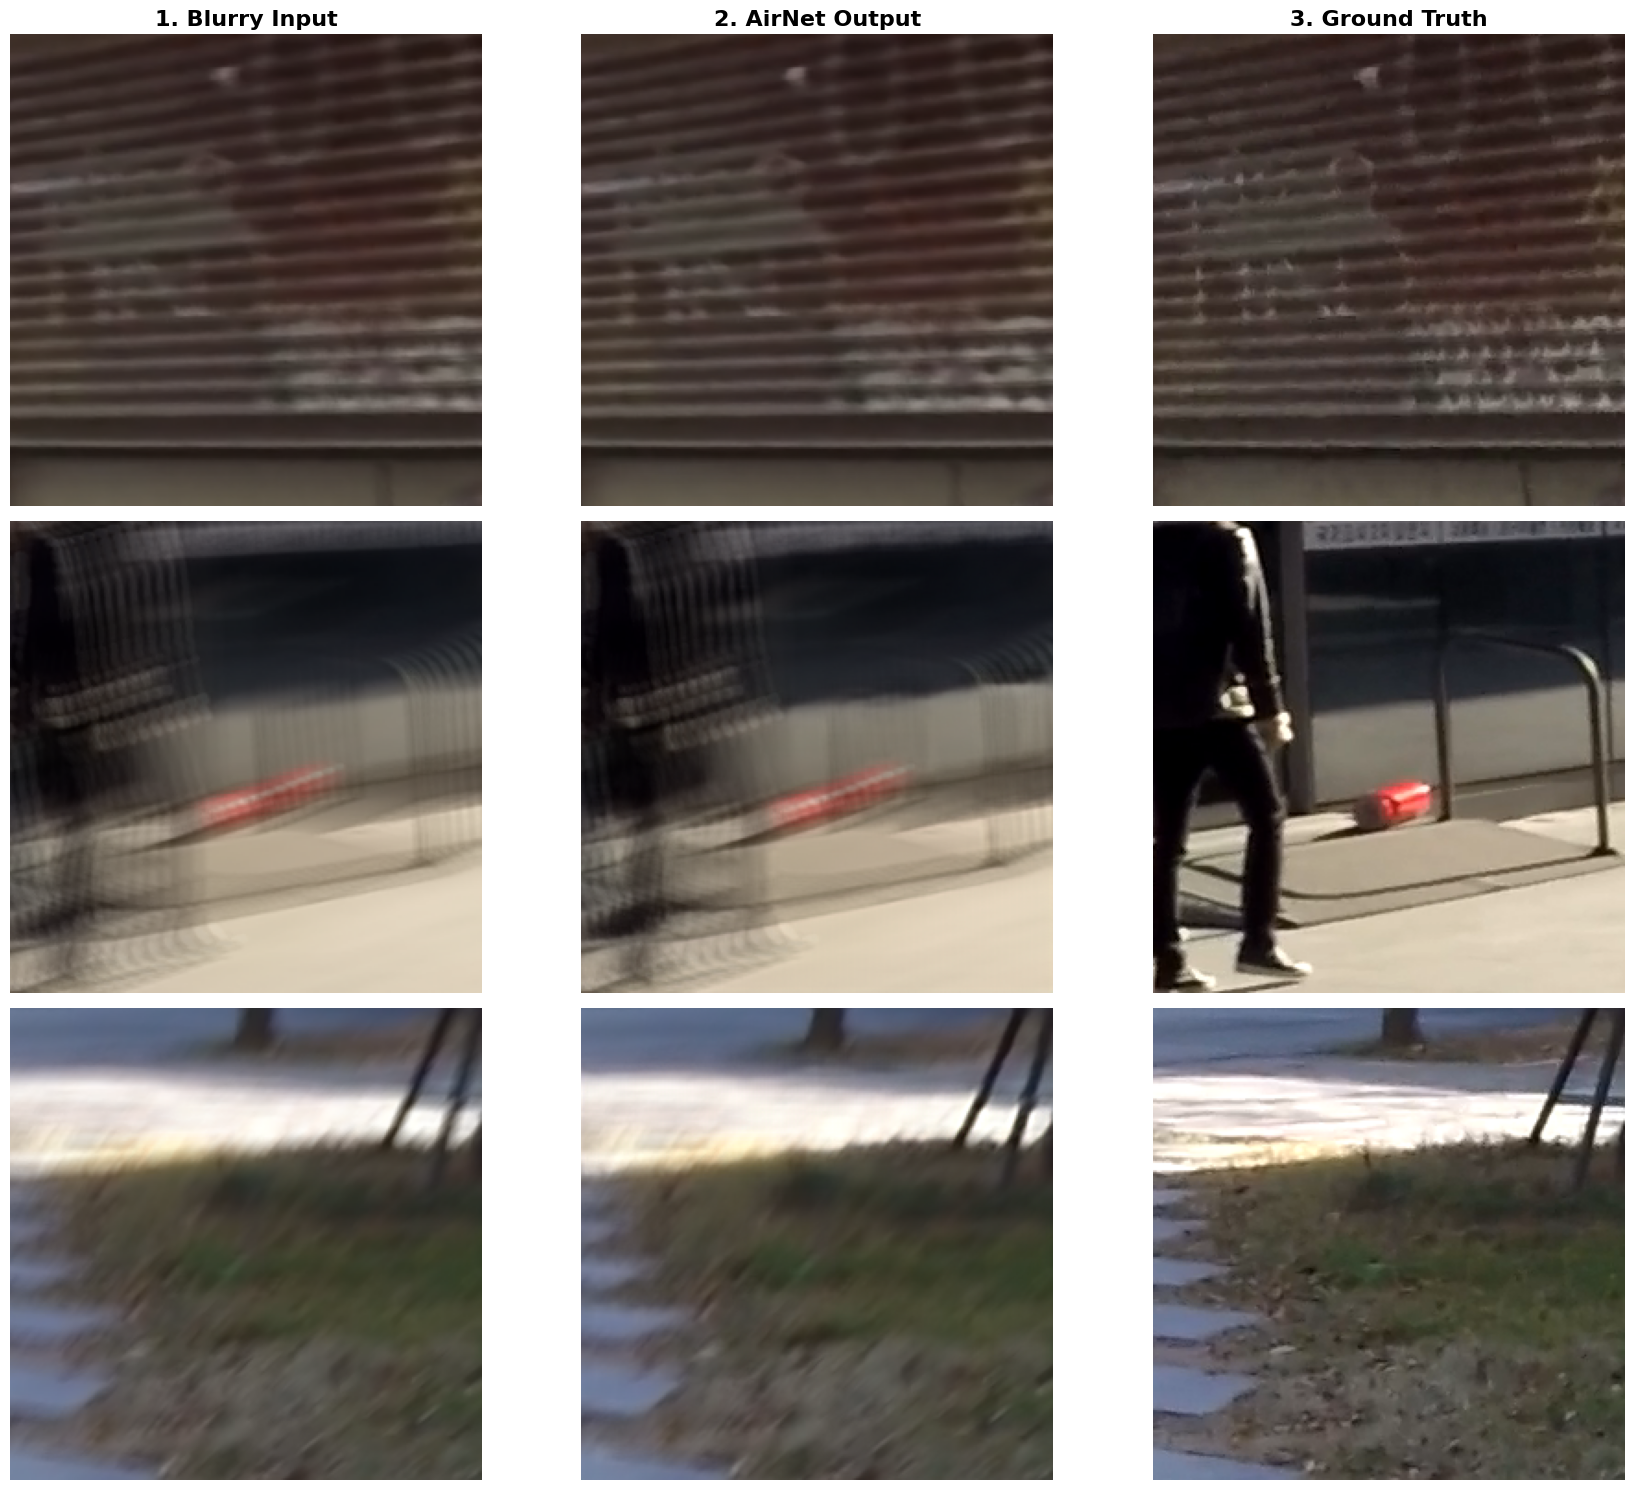

In [7]:
import matplotlib.pyplot as plt
import os
import torch
import glob
import random

# 1. Initialize the empty network (THIS WAS THE MISSING LINE!)
# We need an empty brain to put the downloaded weights into
DEVICE = config.device
airnet = ModifiedAirNet(in_channels=18, out_channels=3).to(DEVICE)

# 2. Search for the attached checkpoints in the Input folder
print("Searching for your 100-epoch models...")
search_path = '/kaggle/input/**/checkpoints/*.pt'
found_models = glob.glob(search_path, recursive=True)

if not found_models:
    print("❌ Could not find any models! Did you add your notebook output in the 'Add Data' menu?")
else:
    # Sort files by the epoch number hidden in the filename
    found_models.sort(key=lambda x: int(x.split('_')[-1].split('.')[0]))
    best_model_path = found_models[-1] # Grabs the very last one (Epoch 100)
    print(f"🎉 Found them! Loading: {best_model_path}")

    # 3. Load the Best AirNet Weights
    airnet.load_state_dict(torch.load(best_model_path, map_location=DEVICE))
    airnet.eval() # Lock it for testing

    # 4. Setup the Visualization Plot (3 rows, 3 columns)
    num_samples = 3
    fig, axes = plt.subplots(num_samples, 3, figsize=(18, 5 * num_samples))
    
    print("\nProcessing unseen test images...")

    with torch.no_grad():
        for i in range(num_samples):
            # Pick a random image from the test dataset
            idx = random.randint(0, len(test_dataset) - 1)
            blur, sharp = test_dataset[idx]
            
            # Add batch dimension and move to GPU
            blur_batch = blur.unsqueeze(0).to(DEVICE)

            # --- THE PIPELINE ---
            factors, _ = model.factNet(blur_batch, epoch=50)
            stacked = torch.cat([blur_batch, factors], dim=1)
            pred_sharp = airnet(stacked)

            # Convert tensors back to numpy images for plotting
            blur_img = blur.permute(1, 2, 0).cpu().numpy()
            pred_img = pred_sharp.squeeze(0).permute(1, 2, 0).cpu().clamp(0, 1).numpy()
            sharp_img = sharp.permute(1, 2, 0).cpu().numpy()

            # --- PLOTTING ---
            axes[i, 0].imshow(blur_img)
            axes[i, 0].axis('off')
            if i == 0: axes[i, 0].set_title("1. Blurry Input", fontsize=16, fontweight='bold')

            axes[i, 1].imshow(pred_img)
            axes[i, 1].axis('off')
            if i == 0: axes[i, 1].set_title(f"2. AirNet Output", fontsize=16, fontweight='bold')

            axes[i, 2].imshow(sharp_img)
            axes[i, 2].axis('off')
            if i == 0: axes[i, 2].set_title("3. Ground Truth", fontsize=16, fontweight='bold')

    plt.tight_layout()
    plt.show()

In [ ]:
import os
import torch
import random
import matplotlib.pyplot as plt

# 1. Smart Checkpoint Finder
SAVE_DIR = '/kaggle/working/checkpoints'
checkpoints = [f for f in os.listdir(SAVE_DIR) if f.endswith('.pt')]

if not checkpoints:
    print("❌ No models found! Are you sure the training finished?")
else:
    # Sort files by the epoch number hidden in the filename
    checkpoints.sort(key=lambda x: int(x.split('_')[2].split('.')[0]))
    best_model_name = checkpoints[-1] # Grabs the last one (highest epoch)
    print(f"🎉 Found trained models! Loading the best one: {best_model_name}")

    # Load the best weights
    best_model_path = os.path.join(SAVE_DIR, best_model_name)
    airnet.load_state_dict(torch.load(best_model_path, map_location=DEVICE))
    airnet.eval() # Lock it into testing mode

    # 2. Setup the Visualization Plot (3 rows, 3 columns)
    num_samples = 3
    fig, axes = plt.subplots(num_samples, 3, figsize=(18, 5 * num_samples))
    
    print("\nProcessing unseen test images...")

    with torch.no_grad():
        for i in range(num_samples):
            # Pick a random image from the 200+ test images
            idx = random.randint(0, len(test_dataset) - 1)
            blur, sharp = test_dataset[idx]
            
            # Add batch dimension and move to GPU
            blur_batch = blur.unsqueeze(0).to(DEVICE)

            # --- THE PIPELINE ---
            # Extract frozen factors
            factors, _ = model.factNet(blur_batch, epoch=50)
            # Stack into 18 channels
            stacked = torch.cat([blur_batch, factors], dim=1)
            # Restore the image!
            pred_sharp = airnet(stacked)

            # Convert tensors back to numpy images for plotting
            blur_img = blur.permute(1, 2, 0).cpu().numpy()
            
            # Clamp ensures pixel values stay in [0, 1] range to avoid matplotlib color warnings
            pred_img = pred_sharp.squeeze(0).permute(1, 2, 0).cpu().clamp(0, 1).numpy()
            sharp_img = sharp.permute(1, 2, 0).cpu().numpy()

            # --- PLOTTING ---
            axes[i, 0].imshow(blur_img)
            axes[i, 0].axis('off')
            if i == 0: axes[i, 0].set_title("1. Blurry Input", fontsize=16, fontweight='bold')

            axes[i, 1].imshow(pred_img)
            axes[i, 1].axis('off')
            if i == 0: axes[i, 1].set_title(f"2. AirNet Output", fontsize=16, fontweight='bold')

            axes[i, 2].imshow(sharp_img)
            axes[i, 2].axis('off')
            if i == 0: axes[i, 2].set_title("3. Ground Truth", fontsize=16, fontweight='bold')

    plt.tight_layout()
    plt.show()

In [8]:
import torch
import numpy as np
from torch.utils.data import DataLoader
from tqdm.auto import tqdm
from skimage.metrics import peak_signal_noise_ratio as calculate_psnr
from skimage.metrics import structural_similarity as calculate_ssim
import warnings

# Suppress annoying skimage warnings
warnings.filterwarnings("ignore", category=UserWarning)

# 1. Create a Dataloader specifically for testing
# We use batch_size=1 so we can calculate metrics image by image accurately
test_loader = DataLoader(test_dataset, batch_size=1, shuffle=False, num_workers=0)

print(f"🧪 Starting Quantitative Evaluation on {len(test_dataset)} test images...")

# 2. Ensure model is in eval mode and loaded with the best weights
# (Assuming Cell 6 already loaded the best epoch, but we do it here just in case)
airnet.eval()

total_psnr = 0.0
total_ssim = 0.0

# 3. The Testing Loop
with torch.no_grad():
    pbar = tqdm(test_loader, desc="Evaluating Test Set")
    
    for blur, sharp in pbar:
        # Move to GPU
        blur = blur.to(DEVICE)
        
        # --- Run the Model ---
        factors, _ = model.factNet(blur, epoch=50)
        stacked = torch.cat([blur, factors], dim=1)
        pred_sharp = airnet(stacked)
        
        # --- Convert Tensors to Numpy Arrays for Metric Calculation ---
        # Move to CPU, remove batch dimension, rearrange channels to [H, W, C], and clamp
        pred_np = pred_sharp.squeeze(0).permute(1, 2, 0).cpu().clamp(0, 1).numpy()
        sharp_np = sharp.squeeze(0).permute(1, 2, 0).cpu().numpy()
        
        # --- Calculate Metrics ---
        # data_range is 1.0 because our image tensors are between 0 and 1
        current_psnr = calculate_psnr(sharp_np, pred_np, data_range=1.0)
        
        # SSIM needs to know which axis represents the color channels (axis 2)
        current_ssim = calculate_ssim(sharp_np, pred_np, data_range=1.0, channel_axis=2)
        
        total_psnr += current_psnr
        total_ssim += current_ssim
        
        # Update progress bar with running averages
        pbar.set_postfix({
            'Avg PSNR': f"{(total_psnr / (pbar.n + 1)):.2f}",
            'Avg SSIM': f"{(total_ssim / (pbar.n + 1)):.4f}"
        })

# 4. Final Results!
final_psnr = total_psnr / len(test_loader)
final_ssim = total_ssim / len(test_loader)

print("\n" + "="*50)
print("🏆 FINAL TEST SET PERFORMANCE 🏆")
print("="*50)
print(f"Total Test Images : {len(test_dataset)}")
print(f"Average PSNR      : {final_psnr:.2f} dB")
print(f"Average SSIM      : {final_ssim:.4f}")
print("="*50)

🧪 Starting Quantitative Evaluation on 206 test images...


Evaluating Test Set:   0%|          | 0/206 [00:00<?, ?it/s]


🏆 FINAL TEST SET PERFORMANCE 🏆
Total Test Images : 206
Average PSNR      : 27.97 dB
Average SSIM      : 0.8131
